# Hamiltonian Flow Matching - Alternating Forward/Backward Stunnel Test

This notebook trains two velocity fields on the stunnel potential:

- `fwd_model`: source -> target
- `bwd_model`: target -> source

The coupling dataset is rebuilt during training. Each alternating epoch flows fresh samples through the opposite NODE, uses that NODE trajectory as the initial mean and mean-derivative guess for `MeanStdBVPGaussianPath.batch_solve`, then trains the active model on the solved BVP paths.

EMA copies are updated after every optimizer step and are used for NODE coupling generation and evaluation.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../'))
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader,Dataset
from torchdyn.core import NeuralODE

from torchcfm.hamiltonian import (
    MeanStdBVPGaussianPath, flow_matching_loss,
    FixedCenterThreeBodyPotential,ConfiguredPotential,
    to_numpy, as_particles as _as_particles, make_hamiltonian_node, make_mean_std_bvp_path,
    solve_bvp_paths, train_on_cached_path_pairs, train_on_ot_pairs as _train_on_ot_pairs,
    simulate_model_trajectory, cached_mean_trajectory, trajectory_hamiltonian,plot_trajectories_with_potential
)
from torchcfm.optimal_transport import OTPlanSampler,wasserstein
from torchcfm.models.models_v2 import MLP,FourierTimeResidualMLP
from torchcfm.utils import torch_wrapper

from ema_pytorch import EMA

if torch.cuda.is_available() and torch.cuda.device_count() > 2:
    device = torch.device('cuda:2')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

import copy

from torch.distributions import MultivariateNormal


In [2]:
# import sys, os
# sys.path.insert(0, os.path.abspath('../../../'))

# import torch
# if torch.cuda.is_available() and torch.cuda.device_count() > 2:
#     device = torch.device('cuda:2')
# elif torch.cuda.is_available():
#     device = torch.device('cuda')
# else:
#     device = torch.device('cpu')

# import numpy as np
# import matplotlib.pyplot as plt
# from torch.distributions import MultivariateNormal
# from torch.utils.data import DataLoader, Dataset
# from torchdyn.core import NeuralODE

# from torchcfm.hamiltonian import (
#     CrowdNavObstaclePotential, ParticleBVPGaussianPath, ConfiguredPotential,
#     MeanStdBVPGaussianPath, flow_matching_loss,
#     plot_trajectories_with_potential,
# )
# from torchcfm.optimal_transport import OTPlanSampler
# from torchcfm.models.models_v2 import MLP,FourierTimeResidualMLP
# from torchcfm.utils import torch_wrapper

# from ema_pytorch import EMA


def to_numpy(x):
    return x.detach().cpu().numpy()


In [ ]:
torch.manual_seed(0)
np.random.seed(0)

# Problem size and training controls.
dim              = 2 
batch_size = 2**8
n_dataset = 2**8
n_epochs = 40
n_iters = 248
n_warmup_iters = 5000
batch_size_warmup = 1024
lr = 5e-4
bvp_sigma = 1e-4
quadrature_order = 3
n_steps = 100
tol = 1e-2
eval_batch = 2500
diagnostic_batch = eval_batch
block_size = 2
solve_t_span = torch.linspace(0, 1, n_steps + 1, device=device)

ema_beta = 0.9999
ema_update_after_step = 0
ema_update_every = 20
ema_freeze_batches = 0
ema_diag_every = ema_update_every
# fwd_ema = None

source_mean      = torch.tensor([-11.0, -1.0], device=device)
target_mean      = torch.tensor([11.0, 1.0], device=device)
gaussian_std     = torch.tensor(0.5, device=device)
solve_t_span     = torch.linspace(0, 1, n_steps + 1, device=device)

eval_batch       = 5000
print(f'device: {device}')


device: cuda


## Distributions and Potential

In [7]:
source_dist = MultivariateNormal(source_mean, gaussian_std**2 * torch.eye(dim, device=device))
target_dist = MultivariateNormal(target_mean, gaussian_std**2 * torch.eye(dim, device=device))

class TotalDataset(Dataset):
        
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return self.samples.shape[0]
    def __getitem__(self,idx):
        return self.samples[idx]
    
source_data = source_dist.sample((n_dataset,))
target_data = target_dist.sample((n_dataset,))

source_loader = DataLoader(TotalDataset(source_data),batch_size = batch_size, shuffle = True, drop_last = True)
target_loader = DataLoader(TotalDataset(target_data),batch_size = batch_size, shuffle = True, drop_last = True)

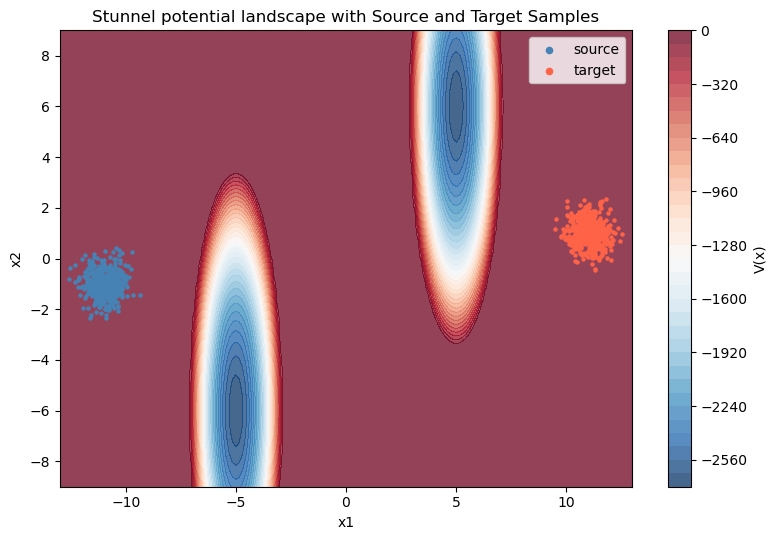

In [10]:


def sample_source(n):
    return source_dist.sample((n,)).to(device)


def sample_target(n):
    return target_dist.sample((n,)).to(device)


cfg_potential = {'linear': ('stunnel', -30), 'interaction': None, 'internal': None} #("rational_quadratic", -0.0)
potential = ConfiguredPotential(cfg_potential)
stunnel_centers = torch.tensor([[5.0, 6.0], [-5.0, -6.0]], device=device)

# Visualize potential landscape with source and target samples.
x_grid = np.linspace(-13, 13, 180)
y_grid = np.linspace(-9, 9, 140)
X, Y = np.meshgrid(x_grid, y_grid)
xy = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32, device=device)

with torch.no_grad():
    Z = to_numpy(potential.energy(xy)).reshape(Y.shape)

x0_vis = to_numpy(source_data)
x1_vis = to_numpy(target_data)


plt.figure(figsize=(8, 5.5))
plt.contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.75)
plt.colorbar(label='V(x)')
plt.scatter(x0_vis[:, 0], x0_vis[:, 1], s=5, c='steelblue', label='source')
plt.scatter(x1_vis[:, 0], x1_vis[:, 1], s=5, c='tomato', label='target')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(markerscale=2)
plt.title(f'{cfg_potential["linear"][0].capitalize()} potential landscape with Source and Target Samples')
plt.tight_layout()
plt.show()


## Models and BVP Helpers

In [132]:
# ot_sampler = OTPlanSampler(method='exact')

# fwd_model = MLP(dim + 1, out_dim=dim, w=256).to(device)
# bwd_model = MLP(dim + 1, out_dim=dim, w=256).to(device)
# fwd_optimizer = torch.optim.AdamW(fwd_model.parameters(), lr=lr)
# bwd_optimizer = torch.optim.AdamW(bwd_model.parameters(), lr=lr)




# def mean_param_delta(model, ema_model):
#     deltas = []
#     with torch.no_grad():
#         for param, ema_param in zip(model.parameters(), ema_model.parameters()):
#             deltas.append((param - ema_param).abs().mean())
#     if not deltas:
#         return 0.0
#     return torch.stack(deltas).mean().item()


# def print_ema_diagnostic(context, generation_model=None):
#     fwd_step = int(fwd_ema.step.item()) if fwd_ema is not None else -1
#     bwd_step = int(bwd_ema.step.item()) if bwd_ema is not None else -1
#     fwd_delta = mean_param_delta(fwd_model, fwd_ema.ema_model) if fwd_ema is not None else float('nan')
#     bwd_delta = mean_param_delta(bwd_model, bwd_ema.ema_model) if bwd_ema is not None else float('nan')
#     generation = f', generation={generation_model}' if generation_model is not None else ''
#     print(
#         f'{context}: fwd_ema_step={fwd_step}, bwd_ema_step={bwd_step}, '
#         f'fwd_delta={fwd_delta:.3e}, bwd_delta={bwd_delta:.3e}{generation}'
#     )


# fwd_losses = []
# bwd_losses = []


# def make_node(model):
#     return NeuralODE(torch_wrapper(model), sensitivity='adjoint', solver='tsit5')


# def trajectory_to_guesses(traj, reverse=True):
#     # traj has shape (time, batch, dim). The BVP path expects (batch, time, dim).
#     if reverse:
#         traj = torch.flip(traj, dims=(0,))
#     traj = traj.detach()
#     if traj.shape[0] != n_steps + 1:
#         raise ValueError(f'Expected {n_steps + 1} trajectory time points, got {traj.shape[0]}.')

#     dt = 1.0 / n_steps
#     mu_dot = torch.empty_like(traj)
#     mu_dot[0] = (traj[1] - traj[0]) / dt
#     mu_dot[-1] = (traj[-1] - traj[-2]) / dt
#     mu_dot[1:-1] = (traj[2:] - traj[:-2]) / (2.0 * dt)

#     mu_guess = to_numpy(traj.permute(1, 0, 2).contiguous())
#     mu_dot_guess = to_numpy(mu_dot.permute(1, 0, 2).contiguous())
#     return mu_guess, mu_dot_guess


# def make_path(mu_guess=None, mu_dot_guess=None)->MeanStdBVPGaussianPath:
#     ''' 
#     Creates a MeanStdBVPGaussianPath instance with the given mean and mean derivative guesses. If no guesses are provided, the path will be initialized without them
#     '''
#     sigma_guess = None
#     sigma_dot_guess = None
#     if mu_guess is not None:
#         n_pairs = mu_guess.shape[0]
#         sigma_guess = np.full((n_pairs, n_steps + 1), sigma_path, dtype=float)
#         sigma_dot_guess = np.zeros((n_pairs, n_steps + 1), dtype=float)

#     return MeanStdBVPGaussianPath(
#         potential,
#         sigma=sigma_path,
#         n_steps=n_steps,
#         tol=tol,
#         mu_guess=mu_guess,
#         mu_dot_guess=mu_dot_guess,
#         sigma_guess=sigma_guess,
#         sigma_dot_guess=sigma_dot_guess,
#         quadrature_order = quadrature_order,
#     )


# def solve_bvp_paths(x0, x1, mu_guess=None, mu_dot_guess=None, label='path'):
#     path = make_path(mu_guess, mu_dot_guess)
#     print(f'Solving {x0.shape[0]} {label} mean/std BVPs...')
#     states = path.batch_solve(x0, x1)
#     keep = path.success_mask.to(device=x0.device)
#     x0_keep = x0[keep]
#     x1_keep = x1[keep]
#     n_failed = int((~keep).sum().item())
#     print(f'{label}: kept {x0_keep.shape[0]} / {keep.numel()} BVPs; failed {n_failed}; states: {states.shape}')
#     if n_failed:
#         preview = list(path.failure_messages.items())[:5]
#         print(f'{label}: first failures: {preview}')
#     return path, x0_keep, x1_keep, states


# def train_on_cached_paths(model, optimizer, path, x0, x1, n_steps_train, label, ema=None, log_every=500):
#     model.train()
#     step_losses = []
#     n_pairs = x0.shape[0]
#     if n_pairs == 0:
#         raise RuntimeError(f'{label}: no successful BVP pairs to train on.')

#     x0 = x0.to(device)
#     x1 = x1.to(device)
#     for step in range(n_steps_train):
#         optimizer.zero_grad()

#         idx = torch.randint(0, n_pairs, (batch_size,), device=device)
#         x0_b = x0[idx]
#         x1_b = x1[idx]
#         # t = torch.rand((batch_size, 1), device=device, dtype=x0_b.dtype)
#         z = torch.randn((batch_size,1),device=device, dtype = x0_b.dtype)
#         z_scaled = z*torch.tensor(1.5,device=device)+torch.ones_like(z,device = device)*1.5
#         t = 1/(1+torch.exp(-z_scaled))
#         epsilon = torch.randn_like(x0_b)

#         xt = path.sample_xt(x0_b, x1_b, t, epsilon)
#         ut = path.compute_ut(x0_b, x1_b, t, xt)
#         vt = model(torch.cat([xt, t], dim=-1))
#         loss = flow_matching_loss(vt, ut)

#         loss.backward()
#         optimizer.step()
#         if ema is not None:
#             ema.update()
#         step_losses.append(loss.item())

#         if step % log_every == 0 or step == n_steps_train - 1:
#             print(f'{label} step {step:5d}: loss = {loss.item():.5f}')
#     return step_losses



# def train_on_ot_pairs(model, optimizer, x0, x1, n_steps_train, label, ema=None, log_every=1000):
#     model.train()
#     step_losses = []
#     n_pairs = x0.shape[0]
#     if n_pairs == 0:
#         raise RuntimeError(f'{label}: no OT pairs to train on.')

#     x0 = x0.to(device)
#     x1 = x1.to(device)
#     for step in range(n_steps_train):
#         optimizer.zero_grad()

#         idx = torch.randint(0, n_pairs, (batch_size,), device=device)
#         x0_b = x0[idx]
#         x1_b = x1[idx]
#         t = torch.rand((batch_size, 1), device=device, dtype=x0_b.dtype)

#         xt = (1.0 - t) * x0_b + t * x1_b
#         ut = x1_b - x0_b
#         vt = model(torch.cat([xt, t], dim=-1))
#         loss = flow_matching_loss(vt, ut)

#         loss.backward()
#         optimizer.step()
#         if ema is not None:
#             ema.update()
#         step_losses.append(loss.item())

#         if step % log_every == 0 or step == n_steps_train - 1:
#             print(f'{label} step {step:5d}: loss = {loss.item():.5f}')
#     return step_losses


In [11]:



ot_sampler = OTPlanSampler(method='exact')

# fwd_model_warmup = MLP(dim, out_dim=dim, w=512, time_varying=True).to(device)
# bwd_model_warmup = MLP(dim, out_dim=dim, w=512, time_varying=True).to(device)
fwd_model_warmup = FourierTimeResidualMLP(dim=dim,out_dim=dim,w=512,hidden=6,m=6,time_varying=True).to(device)
bwd_model_warmup = FourierTimeResidualMLP(dim=dim,out_dim=dim,w=512,hidden=6,m=6,time_varying=True).to(device)
fwd_optimizer = torch.optim.Adam(fwd_model_warmup.parameters(), lr=1e-5)
bwd_optimizer = torch.optim.Adam(bwd_model_warmup.parameters(), lr=1e-5)

fwd_losses = []
bwd_losses = []


def make_node(model):
    return make_hamiltonian_node(model)


def make_path(mu_guess=None, mu_dot_guess=None):
    return make_mean_std_bvp_path(
        potential,
        sigma=bvp_sigma,
        n_steps=n_steps,
        tol=tol,
        quadrature_order=quadrature_order,
        mu_guess=mu_guess,
        mu_dot_guess=mu_dot_guess,
        use_monte_carlo = True,
        monte_carlo_samples = 100,
        
    )


def solve_paths(x0, x1, label="path", mu_guess=None, mu_dot_guess=None):
    def make_path_with_guesses():
        return make_path(mu_guess=mu_guess, mu_dot_guess=mu_dot_guess)

    return solve_bvp_paths(make_path_with_guesses, x0, x1, label=label, description="fixed-center three-body BVPs")


def trajectory_velocity_guesses(model, traj, t_span, x0, x1, reverse=True):
    if traj.ndim != 3:
        raise ValueError(f"traj must have shape (time, batch, dim); got {tuple(traj.shape)}.")
    if traj.shape[0] != t_span.numel():
        raise ValueError(f"traj has {traj.shape[0]} time steps, but t_span has {t_span.numel()}.")
    if traj.shape[0] != n_steps + 1:
        raise ValueError(f"traj must have n_steps + 1 = {n_steps + 1} time steps; got {traj.shape[0]}.")

    batch, guess_dim = traj.shape[1], traj.shape[2]
    x0_flat = x0.detach().reshape(x0.shape[0], -1)
    x1_flat = x1.detach().reshape(x1.shape[0], -1)
    if x0_flat.shape != (batch, guess_dim) or x1_flat.shape != (batch, guess_dim):
        raise ValueError(
            f"Endpoint shapes must flatten to {(batch, guess_dim)}; "
            f"got {tuple(x0_flat.shape)} and {tuple(x1_flat.shape)}."
        )

    was_training = model.training
    model.eval()
    with torch.no_grad():
        t_values = t_span.to(device=traj.device, dtype=traj.dtype).reshape(-1)
        velocities = []
        for k, t_value in enumerate(t_values):
            t_col = t_value.reshape(1, 1).expand(batch, 1)
            velocities.append(model(torch.cat([traj[k], t_col], dim=-1)))
        mu_dot = torch.stack(velocities, dim=0)
    if was_training:
        model.train()

    mu = traj.detach()
    if reverse:
        mu = torch.flip(mu, dims=(0,))
        mu_dot = -torch.flip(mu_dot, dims=(0,))

    mu_guess = mu.permute(1, 0, 2).contiguous().clone()
    mu_dot_guess = mu_dot.permute(1, 0, 2).contiguous().detach().clone()
    x0_flat = x0_flat.to(device=mu_guess.device, dtype=mu_guess.dtype)
    x1_flat = x1_flat.to(device=mu_guess.device, dtype=mu_guess.dtype)
    mu_guess[:, 0, :] = x0_flat
    mu_guess[:, -1, :] = x1_flat

    assert mu_guess.shape == mu_dot_guess.shape == (batch, n_steps + 1, guess_dim)
    assert torch.allclose(mu_guess[:, 0, :], x0_flat)
    assert torch.allclose(mu_guess[:, -1, :], x1_flat)
    return to_numpy(mu_guess), to_numpy(mu_dot_guess)


def train_on_cached_paths(model, optimizer, path, x0, x1, n_steps_train, label, ema=None, log_every=200):
    return train_on_cached_path_pairs(
        model, optimizer, path, x0, x1, n_steps_train, label, ema=ema,
        batch_size=batch_size,
        device=device,
        log_every=log_every,
        no_pairs_message="no successful BVP pairs to train on",
    )


def train_on_ot_pairs(model, optimizer, x0, x1, n_steps_train, label, log_every=500):
    return _train_on_ot_pairs(
        model, optimizer, x0, x1, n_steps_train, label,
        batch_size=batch_size,
        device=device,
        log_every=log_every,
    )

In [12]:
ema_beta = 0.9999
ema_update_after_step = 0
ema_update_every = 1
ema_freeze_batches = 0
ema_diag_every = ema_update_every

# fwd_optimizer = torch.optim.AdamW(fwd_model.parameters(), lr=1e-5)
# bwd_optimizer = torch.optim.AdamW(bwd_model.parameters(), lr=1e-5)


def mean_param_delta(model, ema_model):
    deltas = []
    with torch.no_grad():
        for param, ema_param in zip(model.parameters(), ema_model.parameters()):
            deltas.append((param - ema_param).abs().mean())
    if not deltas:
        return 0.0
    return torch.stack(deltas).mean().item()


def print_ema_diagnostic(context, generation_model=None):
    fwd_step = int(fwd_ema.step.item()) if fwd_ema is not None else -1
    bwd_step = int(bwd_ema.step.item()) if bwd_ema is not None else -1
    fwd_delta = mean_param_delta(fwd_model, fwd_ema.ema_model) if fwd_ema is not None else float('nan')
    bwd_delta = mean_param_delta(bwd_model, bwd_ema.ema_model) if bwd_ema is not None else float('nan')
    generation = f', generation={generation_model}' if generation_model is not None else ''
    print(
        f'{context}: fwd_ema_step={fwd_step}, bwd_ema_step={bwd_step}, '
        f'fwd_delta={fwd_delta:.3e}, bwd_delta={bwd_delta:.3e}{generation}'
    )

fwd_model = FourierTimeResidualMLP(dim=dim,out_dim=dim,w=512,hidden=6,m=6,time_varying=True).to(device)
bwd_model = FourierTimeResidualMLP(dim=dim,out_dim=dim,w=512,hidden=6,m=6,time_varying=True).to(device)
fwd_losses = []
bwd_losses = []
# fwd_model = copy.deepcopy(fwd_model_warmup)
# bwd_model = copy.deepcopy(bwd_model_warmup)
# fwd_ema = None
# bwd_ema = None
fwd_ema = EMA(
    fwd_model,
    beta=ema_beta,
    update_after_step=ema_update_after_step,
    update_every=ema_update_every,
    min_value=ema_beta,
).to(device)
# bwd_ema = None
bwd_ema = EMA(
    bwd_model,
    beta=ema_beta,
    update_after_step=ema_update_after_step,
    update_every=ema_update_every,
    min_value=ema_beta,
).to(device)

# # Initialize EMA from the warm-started online models once, then let the slow schedule control drift.
# fwd_ema.update()
# bwd_ema.update()
# print_ema_diagnostic('EMA initialized from warm-start models')


In [13]:
last_fwd_path = None
last_bwd_path = None
last_fwd_states = None
last_bwd_states = None
last_fwd_x0, last_fwd_x1 = None, None
last_bwd_x0, last_bwd_x1 = None, None
eval_t_span = torch.linspace(0, 1, 100, device=device)

x0_eval = sample_source(eval_batch//10)
x1_eval = sample_target(eval_batch//10)
bwd_optimizer = torch.optim.AdamW(bwd_model.parameters(), lr=1e-4)
fwd_optimizer = torch.optim.AdamW(fwd_model.parameters(), lr=1e-4)


def select_generation_model(ema, online_model, ema_name, online_name):
    if ema is not None:
        generation_model = ema.ema_model
        generation_label = ema_name
    else:
        generation_model = online_model
        generation_label = online_name
    generation_model.eval()
    return generation_model, generation_label


def generate_fwd_path_cache(epoch, batch_idx, y_target, x_source, generation_model):
    mu_guess, mu_dot_guess = None, None
    if epoch == 0:
        x_source, y_target = ot_sampler.sample_plan(x_source, y_target)
        pass
    else:
        generation_node = make_node(generation_model)
        with torch.no_grad():
            bwd_traj = generation_node.trajectory(y_target, t_span=solve_t_span)
        generated_source = bwd_traj[-1].detach()
        generated_source, x_source, bwd_traj_guess, _ = ot_sampler.sample_plan_with_labels(
            generated_source,
            x_source,
            y0=bwd_traj.permute(1, 0, 2).contiguous(),
            y1=None,
        )
        y_target = bwd_traj_guess[:, 0, :].detach()
        bwd_traj_guess = bwd_traj_guess.permute(1, 0, 2).contiguous()
        mu_guess, mu_dot_guess = trajectory_velocity_guesses(
            generation_model,
            bwd_traj_guess,
            solve_t_span,
            x_source,
            y_target,
            reverse=True,
        )

    path, x0_keep, x1_keep, states = solve_paths(
        x_source,
        y_target,
        label=f'epoch {epoch} batch {batch_idx} fwd',
        mu_guess=mu_guess,
        mu_dot_guess=mu_dot_guess,
    )
    return {
        'path': path,
        'x0': x0_keep,
        'x1': x1_keep,
        'states': states,
        'label': f'epoch {epoch} batch {batch_idx} fwd',
    }


def generate_bwd_path_cache(epoch, batch_idx, x_source, y_target, generation_model):
    mu_guess, mu_dot_guess = None, None
    if epoch == 0:
        x_source, y_target = ot_sampler.sample_plan(x_source, y_target)
    else:
        generation_node = make_node(generation_model)
        with torch.no_grad():
            fwd_traj = generation_node.trajectory(x_source, t_span=solve_t_span)
        generated_target = fwd_traj[-1].detach()
        generated_target, y_target, fwd_traj_guess, _ = ot_sampler.sample_plan_with_labels(
            generated_target,
            y_target,
            y0=fwd_traj.permute(1, 0, 2).contiguous(),
            y1=None,
        )
        x_source = fwd_traj_guess[:, 0, :].detach()
        fwd_traj_guess = fwd_traj_guess.permute(1, 0, 2).contiguous()
        mu_guess, mu_dot_guess = trajectory_velocity_guesses(
            generation_model,
            fwd_traj_guess,
            solve_t_span,
            y_target,
            x_source,
            reverse=True,
        )

    path, x0_keep, x1_keep, states = solve_paths(
        y_target,
        x_source,
        label=f'epoch {epoch} batch {batch_idx} bwd',
        mu_guess=mu_guess,
        mu_dot_guess=mu_dot_guess,
    )
    return {
        'path': path,
        'x0': x0_keep,
        'x1': x1_keep,
        'states': states,
        'label': f'epoch {epoch} batch {batch_idx} bwd',
    }


def train_fwd_on_path_cache(cache):
    return train_on_cached_path_pairs(
        fwd_model,
        fwd_optimizer,
        cache['path'],
        cache['x0'],
        cache['x1'],
        n_iters,
        cache['label'],
        ema=fwd_ema,
        batch_size=batch_size,
        device=device,
        log_every=200,
        no_pairs_message="no successful BVP pairs to train on",
    )


def train_bwd_on_path_cache(cache):
    return train_on_cached_path_pairs(
        bwd_model,
        bwd_optimizer,
        cache['path'],
        cache['x0'],
        cache['x1'],
        n_iters,
        cache['label'],
        ema=bwd_ema,
        batch_size=batch_size,
        device=device,
        log_every=200,
        no_pairs_message="no successful BVP pairs to train on",
    )


for epoch in range(n_epochs):
    print(f'\n=== Alternating epoch {epoch + 1} / {n_epochs} ===')
    train_fwd = (epoch % 2 == 0)

    source_data = source_dist.sample((n_dataset,))
    target_data = target_dist.sample((n_dataset,))
    source_loader = DataLoader(TotalDataset(source_data), batch_size=batch_size, shuffle=True, drop_last=True)
    target_loader = DataLoader(TotalDataset(target_data), batch_size=batch_size, shuffle=True, drop_last=True)

    if train_fwd:
        bwd_generation_model, generation_model = select_generation_model(
            bwd_ema, bwd_model, 'bwd_ema.ema_model', 'bwd_model'
        )
        print_ema_diagnostic(f'epoch {epoch} fwd cache generation', generation_model=generation_model)
        for i, (y_target, x_source) in enumerate(zip(target_loader, source_loader)):
            fwd_cache = generate_fwd_path_cache(epoch, i, y_target, x_source, bwd_generation_model)
            last_fwd_path = fwd_cache['path']
            last_fwd_x0, last_fwd_x1 = fwd_cache['x0'], fwd_cache['x1']
            last_fwd_states = fwd_cache['states']
            fwd_losses.extend(train_fwd_on_path_cache(fwd_cache))

            with torch.no_grad():
                fwd_model.eval()
                fwd_node = make_node(fwd_model)
                fwd_traj = fwd_node.trajectory(x0_eval, t_span=eval_t_span)
            # plot_learned_three_body_trajectories(
            #     fwd_traj, x0_eval, 'Forward source to target', n_show=fwd_traj.shape[1]
            # )
    else:
        fwd_generation_model, generation_model = select_generation_model(
            fwd_ema, fwd_model, 'fwd_ema.ema_model', 'fwd_model'
        )
        print_ema_diagnostic(f'epoch {epoch} bwd cache generation', generation_model=generation_model)
        for i, (x_source, y_target) in enumerate(zip(source_loader, target_loader)):
            bwd_cache = generate_bwd_path_cache(epoch, i, x_source, y_target, fwd_generation_model)
            last_bwd_path = bwd_cache['path']
            last_bwd_x0, last_bwd_x1 = bwd_cache['x0'], bwd_cache['x1']
            last_bwd_states = bwd_cache['states']
            bwd_losses.extend(train_bwd_on_path_cache(bwd_cache))

            with torch.no_grad():
                bwd_model.eval()
                bwd_node = make_node(bwd_model)
                bwd_traj = bwd_node.trajectory(x1_eval, t_span=eval_t_span)
            # plot_learned_three_body_trajectories(
            #     bwd_traj, x1_eval, 'Backward target to source', n_show=bwd_traj.shape[1]
            # )



=== Alternating epoch 1 / 40 ===
epoch 0 fwd cache generation: fwd_ema_step=0, bwd_ema_step=0, fwd_delta=0.000e+00, bwd_delta=0.000e+00, generation=bwd_ema.ema_model
Solving 512 epoch 0 batch 0 fwd fixed-center three-body BVPs...
epoch 0 batch 0 fwd: kept 397 / 512 BVPs; failed 115; states: torch.Size([397, 101, 6])
epoch 0 batch 0 fwd: first failures: [(4, 'The maximum number of mesh nodes is exceeded.'), (7, 'The maximum number of mesh nodes is exceeded.'), (10, 'The maximum number of mesh nodes is exceeded.'), (13, 'The maximum number of mesh nodes is exceeded.'), (20, 'The maximum number of mesh nodes is exceeded.')]
epoch 0 batch 0 fwd step     0: loss = 341.49725
epoch 0 batch 0 fwd step   200: loss = 3.10994
epoch 0 batch 0 fwd step   247: loss = 2.25954

=== Alternating epoch 2 / 40 ===
epoch 1 bwd cache generation: fwd_ema_step=248, bwd_ema_step=0, fwd_delta=5.114e-03, bwd_delta=0.000e+00, generation=fwd_ema.ema_model
Solving 512 epoch 1 batch 0 bwd fixed-center three-body BV

KeyboardInterrupt: 

## Warmup on Zero-Potential OT Pairs

In [133]:
x0_warm = sample_source(batch_size_warmup)
x1_warm = sample_target(batch_size_warmup)
x0_warm, x1_warm = ot_sampler.sample_plan(x0_warm, x1_warm)

fwd_losses.extend(
    train_on_ot_pairs(
        fwd_model, fwd_optimizer, x0_warm, x1_warm,
        n_warmup_iters, label='warmup fwd', ema=None
    )
)
bwd_losses.extend(
    train_on_ot_pairs(
        bwd_model, bwd_optimizer, x1_warm, x0_warm,
        n_warmup_iters, label='warmup bwd', ema=None
    )
)


warmup fwd step     0: loss = 240.95529
warmup fwd step  1000: loss = 0.05281
warmup fwd step  2000: loss = 0.01938
warmup fwd step  3000: loss = 0.01404
warmup fwd step  4000: loss = 0.00866
warmup fwd step  4999: loss = 0.00564
warmup bwd step     0: loss = 241.72882
warmup bwd step  1000: loss = 0.03836
warmup bwd step  2000: loss = 0.02318
warmup bwd step  3000: loss = 0.00992
warmup bwd step  4000: loss = 0.00756
warmup bwd step  4999: loss = 0.00974


## Alternating Forward/Backward Training

In [134]:
fwd_ema = EMA(
    fwd_model,
    beta=ema_beta,
    update_after_step=ema_update_after_step,
    update_every=ema_update_every,
    min_value=ema_beta,
).to(device)
# bwd_ema = None
bwd_ema = EMA(
    bwd_model,
    beta=ema_beta,
    update_after_step=ema_update_after_step,
    update_every=ema_update_every,
    min_value=ema_beta,
).to(device)

# Initialize EMA from the warm-started online models once, then let the slow schedule control drift.
if fwd_ema is not None:
    fwd_ema.update()
if bwd_ema is not None:
    bwd_ema.update()
print_ema_diagnostic('EMA initialized from warm-start models')


EMA initialized from warm-start models: fwd_ema_step=1, bwd_ema_step=1, fwd_delta=0.000e+00, bwd_delta=0.000e+00


In [135]:
last_fwd_path = None
last_bwd_path = None
last_fwd_states = None
last_bwd_states = None
last_fwd_x0, last_fwd_x1 = None, None
last_bwd_x0, last_bwd_x1 = None, None
ema_alternating_updates = 0

for epoch in range(n_epochs):
    i = 0
    for x_source,y_target in zip(source_loader,target_loader):
        if i % 2 == 0:
            # Train fwd using couplings induced by the current bwd NODE.
            if bwd_ema is not None:
                bwd_ema.ema_model.eval()
                bwd_node = make_node(bwd_ema.ema_model)
                generation_model = 'bwd_ema.ema_model'
            else:
                bwd_model.eval()
                bwd_node = make_node(bwd_model)
                generation_model = 'bwd_model'
            with torch.no_grad():
                bwd_traj = bwd_node.trajectory(y_target, t_span=solve_t_span)
            generated_source = bwd_traj[-1].detach()
            mu_guess, mu_dot_guess = trajectory_to_guesses(bwd_traj, reverse=True)
            last_fwd_path, last_fwd_x0, last_fwd_x1, last_fwd_states = solve_bvp_paths(
                generated_source, y_target, mu_guess, mu_dot_guess, label=f'epoch {epoch} batch {i} fwd'
            )
            fwd_losses.extend(
                train_on_cached_paths(
                    fwd_model, fwd_optimizer, last_fwd_path, last_fwd_x0, last_fwd_x1,
                    n_iters, label=f'epoch {epoch} batch {i} fwd', ema=None
                )
            )
            ema_alternating_updates += 1
            if fwd_ema is not None and ema_alternating_updates > ema_freeze_batches:
                fwd_ema.update()
            if ema_alternating_updates % ema_diag_every == 0:
                print_ema_diagnostic(f'epoch {epoch} batch {i} post-fwd', generation_model)
        else:
            # Train bwd using couplings induced by the current fwd NODE.
            # x_source = sample_source(n_dataset)
            
            if fwd_ema is not None:
                fwd_ema.ema_model.eval()
                fwd_node = make_node(fwd_ema.ema_model)
                generation_model = 'fwd_ema.ema_model'
            else:
                fwd_model.eval()
                fwd_node = make_node(fwd_model)
                generation_model = 'fwd_model'
            with torch.no_grad():
                fwd_traj = fwd_node.trajectory(x_source, t_span=solve_t_span)
            generated_target = fwd_traj[-1].detach()
            mu_guess, mu_dot_guess = trajectory_to_guesses(fwd_traj, reverse=True)

            last_bwd_path, last_bwd_x0, last_bwd_x1, last_bwd_states = solve_bvp_paths(
                generated_target, x_source, mu_guess, mu_dot_guess, label=f'epoch {epoch} batch {i} bwd'
            )
            bwd_losses.extend(
                train_on_cached_paths(
                    bwd_model, bwd_optimizer, last_bwd_path, last_bwd_x0, last_bwd_x1,
                    n_iters, label=f'epoch {epoch} batch {i} bwd', ema=None
                )
            )
            ema_alternating_updates += 1
            if bwd_ema is not None and ema_alternating_updates > ema_freeze_batches:
                bwd_ema.update()
            if ema_alternating_updates % ema_diag_every == 0:
                print_ema_diagnostic(f'epoch {epoch} batch {i} post-bwd', generation_model)
        i += 1


Solving 64 epoch 0 batch 0 fwd mean/std BVPs...
epoch 0 batch 0 fwd: kept 50 / 64 BVPs; failed 14; states: torch.Size([50, 31, 6])
epoch 0 batch 0 fwd: first failures: [(3, 'The maximum number of mesh nodes is exceeded.'), (11, 'The maximum number of mesh nodes is exceeded.'), (16, 'The maximum number of mesh nodes is exceeded.'), (17, 'The maximum number of mesh nodes is exceeded.'), (23, 'The maximum number of mesh nodes is exceeded.')]
epoch 0 batch 0 fwd step     0: loss = 95.82533
epoch 0 batch 0 fwd step   500: loss = 2.43384
epoch 0 batch 0 fwd step   799: loss = 1.32374
Solving 64 epoch 0 batch 1 bwd mean/std BVPs...
epoch 0 batch 1 bwd: kept 47 / 64 BVPs; failed 17; states: torch.Size([47, 31, 6])
epoch 0 batch 1 bwd: first failures: [(1, 'The maximum number of mesh nodes is exceeded.'), (5, 'The maximum number of mesh nodes is exceeded.'), (6, 'The maximum number of mesh nodes is exceeded.'), (11, 'The maximum number of mesh nodes is exceeded.'), (12, 'The maximum number of m

KeyboardInterrupt: 

In [136]:
# last_fwd_path = None
# last_bwd_path = None
# last_fwd_states = None
# last_bwd_states = None
# last_fwd_x0, last_fwd_x1 = None, None
# last_bwd_x0, last_bwd_x1 = None, None

# for epoch in range(n_epochs):
#     if epoch % 2 == 0:
#         # Train fwd using couplings induced by the current bwd NODE.
#         y_target = sample_target(n_dataset)
#         if bwd_ema:
#             bwd_ema.ema_model.eval()
#             bwd_node = make_node(bwd_ema.ema_model)
#         else:
#             bwd_model.eval()
#             bwd_node = make_node(bwd_model)
#         with torch.no_grad():
#             bwd_traj = bwd_node.trajectory(y_target, t_span=solve_t_span)
#         generated_source = bwd_traj[-1].detach()
#         mu_guess, mu_dot_guess = trajectory_to_guesses(bwd_traj, reverse=True)

#         last_fwd_path, last_fwd_x0, last_fwd_x1, last_fwd_states = solve_bvp_paths(
#             generated_source, y_target, mu_guess, mu_dot_guess, label=f'epoch {epoch} fwd'
#         )
#         fwd_losses.extend(
#             train_on_cached_paths(
#                 fwd_model, fwd_optimizer, last_fwd_path, last_fwd_x0, last_fwd_x1,
#                 n_iters, label=f'epoch {epoch} fwd', ema=fwd_ema
#             )
#         )
#     else:
#         # Train bwd using couplings induced by the current fwd NODE.
#         x_source = sample_source(n_dataset)
#         if fwd_ema:
#             fwd_ema.ema_model.eval()
#             fwd_node = make_node(fwd_ema.ema_model)
#         else:
#             fwd_model.eval()
#             fwd_node = make_node(fwd_model)
#         with torch.no_grad():
#             fwd_traj = fwd_node.trajectory(x_source, t_span=solve_t_span)
#         generated_target = fwd_traj[-1].detach()
#         mu_guess, mu_dot_guess = trajectory_to_guesses(fwd_traj, reverse=True)

#         last_bwd_path, last_bwd_x0, last_bwd_x1, last_bwd_states = solve_bvp_paths(
#             generated_target, x_source, mu_guess, mu_dot_guess, label=f'epoch {epoch} bwd'
#         )
#         bwd_losses.extend(
#             train_on_cached_paths(
#                 bwd_model, bwd_optimizer, last_bwd_path, last_bwd_x0, last_bwd_x1,
#                 n_iters, label=f'epoch {epoch} bwd', ema=bwd_ema
#             )
#         )


## Training Losses

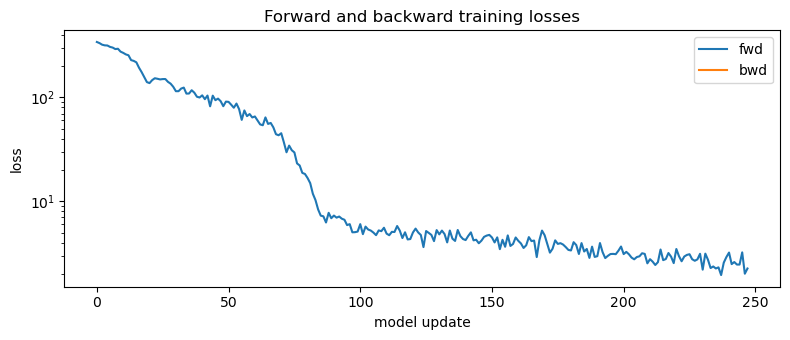

In [14]:
plt.figure(figsize=(8, 3.5))
plt.semilogy(fwd_losses, label='fwd')
plt.semilogy(bwd_losses, label='bwd')
plt.xlabel('model update')
plt.ylabel('loss')
plt.title('Forward and backward training losses')
plt.legend()
plt.tight_layout()
plt.show()


## Last Solved BVP Datasets

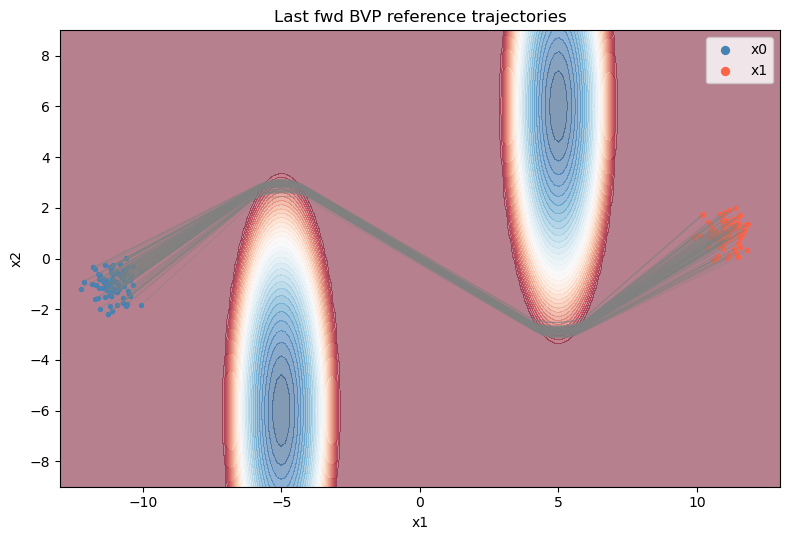

In [15]:
def plot_solved_bvps(states, x0, x1, title, n_show=100):
    n_show = min(n_show, states.shape[0])
    traj_bvp = to_numpy(states[:n_show, :, :dim])
    x0_plot = to_numpy(x0[:n_show])
    x1_plot = to_numpy(x1[:n_show])

    plt.figure(figsize=(8, 5.5))
    plt.contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.5)
    for i in range(n_show):
        plt.plot(traj_bvp[i, :, 0], traj_bvp[i, :, 1], 'gray', alpha=0.45, linewidth=0.7)
    plt.scatter(x0_plot[:, 0], x0_plot[:, 1], s=8, c='steelblue', label='x0')
    plt.scatter(x1_plot[:, 0], x1_plot[:, 1], s=8, c='tomato', label='x1')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend(markerscale=2)
    plt.title(title)
    plt.tight_layout()
    plt.show()


if last_fwd_states is not None:
    plot_solved_bvps(last_fwd_states, last_fwd_x0, last_fwd_x1, 'Last fwd BVP reference trajectories')
if last_bwd_states is not None:
    plot_solved_bvps(last_bwd_states, last_bwd_x0, last_bwd_x1, 'Last bwd BVP reference trajectories')


## Evaluation

In [16]:
# fwd_ema.ema_model.eval()
# bwd_ema.ema_model.eval()
# fwd_node = make_node(fwd_ema.ema_model)
# bwd_node = make_node(bwd_ema.ema_model)
fwd_model.eval()
bwd_model.eval()
fwd_node = make_node(fwd_model)
bwd_node = make_node(bwd_model)
eval_t_span = torch.linspace(0, 1, n_steps+1, device=device)

with torch.no_grad():
    fwd_traj = fwd_node.trajectory(sample_source(eval_batch), t_span=eval_t_span,)
    bwd_traj = bwd_node.trajectory(sample_target(eval_batch), t_span=eval_t_span)

fwd_traj_plot = to_numpy(fwd_traj)
bwd_traj_plot = to_numpy(bwd_traj)


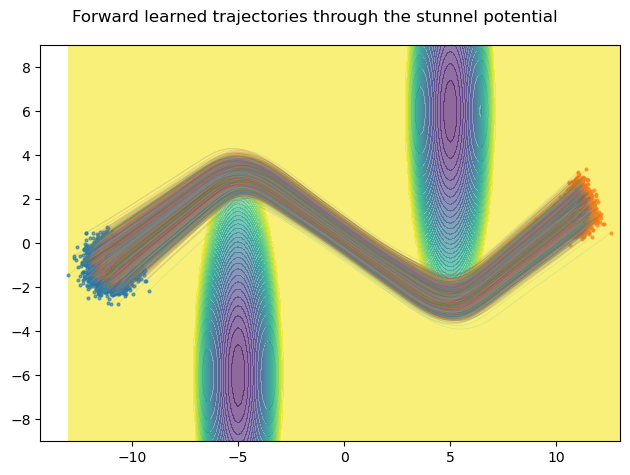

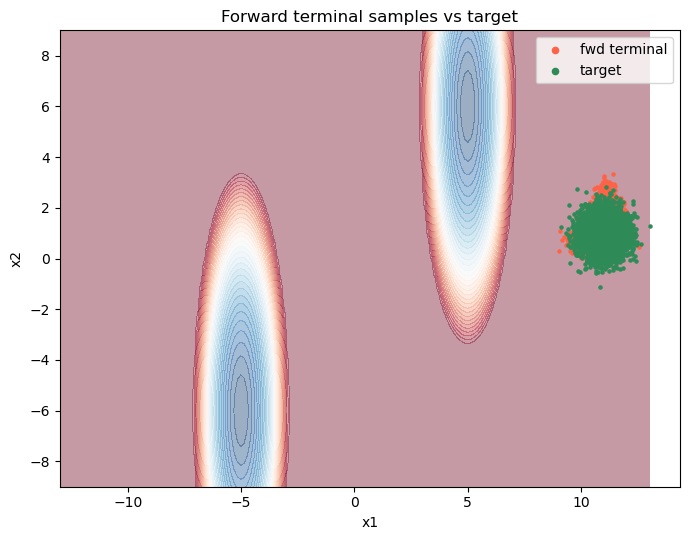

In [21]:
fig = plot_trajectories_with_potential(fwd_traj_plot, X, Y, Z, n=eval_batch)
fig.suptitle('Forward learned trajectories through the stunnel potential')
plt.tight_layout()
plt.show()

x1_ref = to_numpy(sample_target(eval_batch))
plt.figure(figsize=(7, 5.5))
plt.contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.4)
plt.scatter(fwd_traj_plot[-1, :, 0], fwd_traj_plot[-1, :, 1], s=5, c='tomato', label='fwd terminal')
plt.scatter(x1_ref[:, 0], x1_ref[:, 1], s=5, c='seagreen', label='target')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(markerscale=2)
plt.title('Forward terminal samples vs target')
plt.tight_layout()
plt.show()


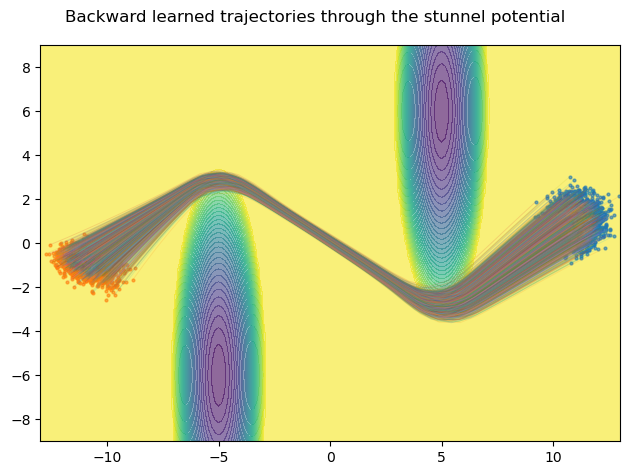

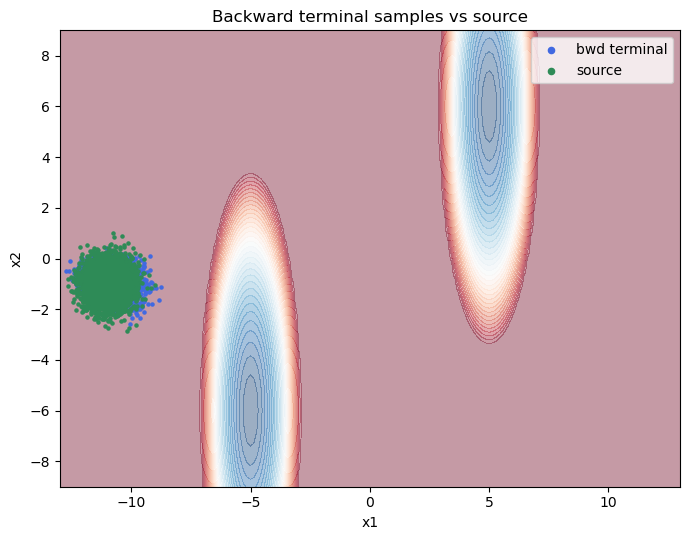

In [142]:
fig = plot_trajectories_with_potential(bwd_traj_plot, X, Y, Z, n=eval_batch)
fig.suptitle('Backward learned trajectories through the stunnel potential')
plt.tight_layout()
plt.show()

x0_ref = to_numpy(sample_source(eval_batch))
plt.figure(figsize=(7, 5.5))
plt.contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.4)
plt.scatter(bwd_traj_plot[-1, :, 0], bwd_traj_plot[-1, :, 1], s=5, c='royalblue', label='bwd terminal')
plt.scatter(x0_ref[:, 0], x0_ref[:, 1], s=5, c='seagreen', label='source')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(markerscale=2)
plt.title('Backward terminal samples vs source')
plt.tight_layout()
plt.show()


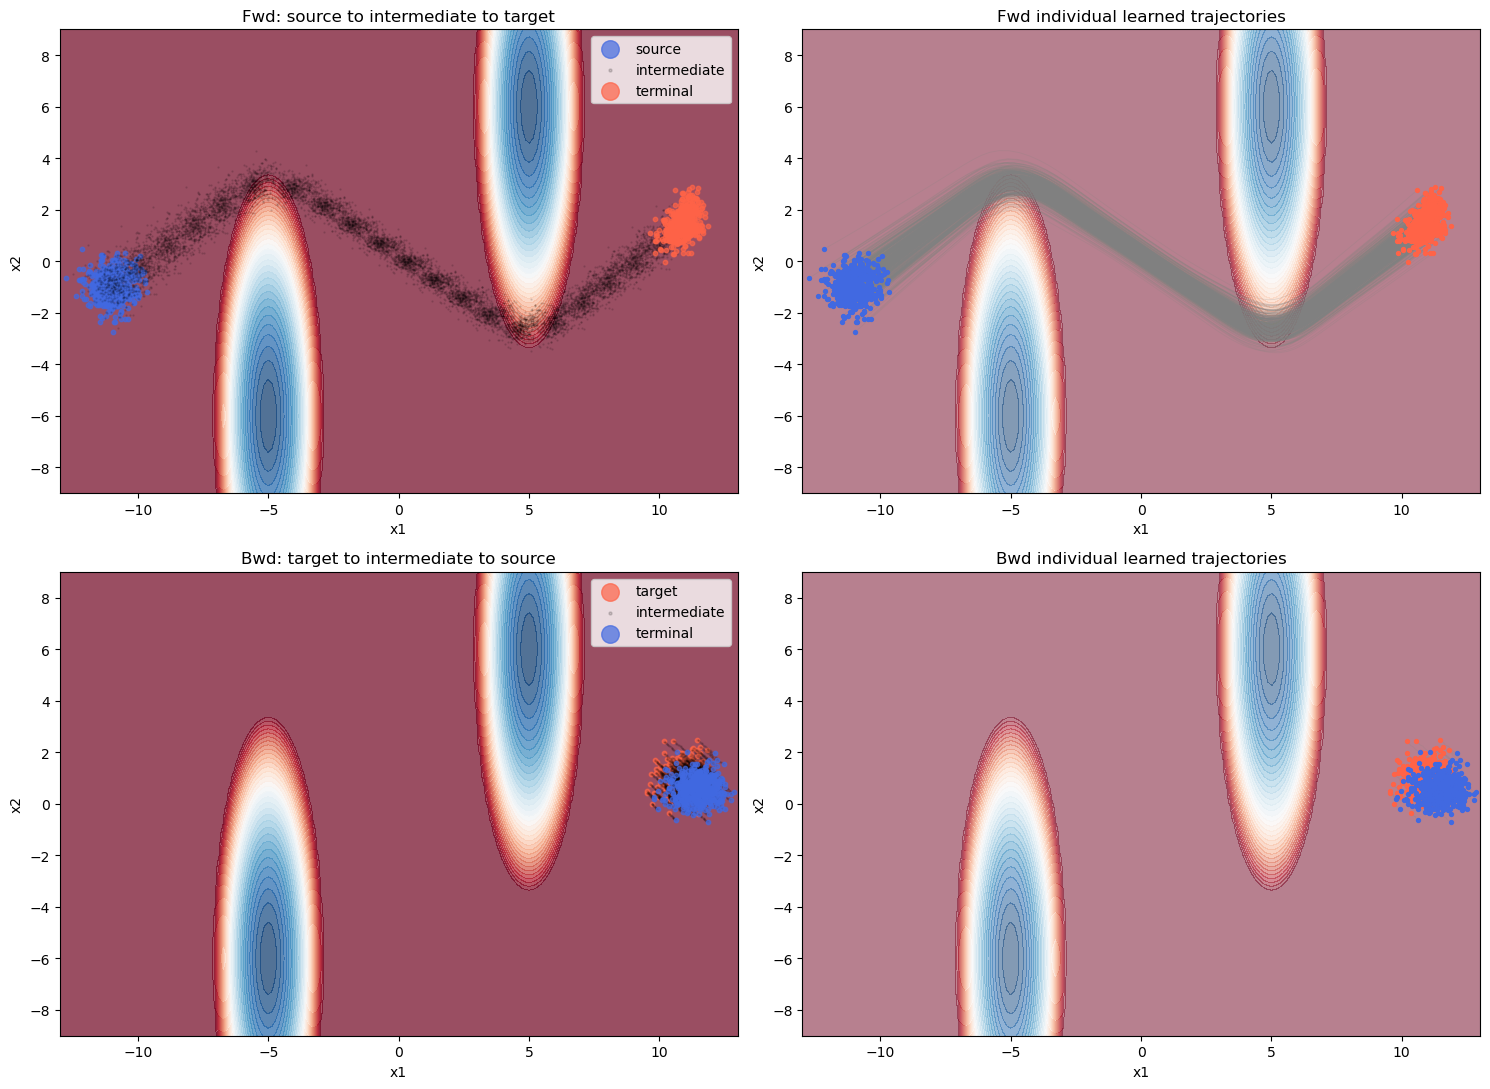

In [18]:
# Source/target, intermediate states, and individual trajectory paths for both directions.
n_show = min(eval_batch, 500)
n_lines = min(eval_batch, 500)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

axes[0, 0].contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.7)
axes[0, 0].scatter(fwd_traj_plot[0, :n_show, 0], fwd_traj_plot[0, :n_show, 1], s=10, alpha=0.7, c='royalblue', label='source')
axes[0, 0].scatter(fwd_traj_plot[1:-1:5, :n_show, 0].reshape(-1), fwd_traj_plot[1:-1:5, :n_show, 1].reshape(-1), s=0.3, alpha=0.15, c='black', label='intermediate')
axes[0, 0].scatter(fwd_traj_plot[-1, :n_show, 0], fwd_traj_plot[-1, :n_show, 1], s=10, alpha=0.7, c='tomato', label='terminal')
axes[0, 0].set_title('Fwd: source to intermediate to target')
axes[0, 0].legend(markerscale=4)

axes[0, 1].contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.5)
for i in range(n_lines):
    axes[0, 1].plot(fwd_traj_plot[:, i, 0], fwd_traj_plot[:, i, 1], 'gray', alpha=0.2, linewidth=0.6)
axes[0, 1].scatter(fwd_traj_plot[0, :n_lines, 0], fwd_traj_plot[0, :n_lines, 1], s=8, c='royalblue', zorder=3)
axes[0, 1].scatter(fwd_traj_plot[-1, :n_lines, 0], fwd_traj_plot[-1, :n_lines, 1], s=8, c='tomato', zorder=3)
axes[0, 1].set_title('Fwd individual learned trajectories')

axes[1, 0].contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.7)
axes[1, 0].scatter(bwd_traj_plot[0, :n_show, 0], bwd_traj_plot[0, :n_show, 1], s=10, alpha=0.7, c='tomato', label='target')
axes[1, 0].scatter(bwd_traj_plot[1:-1:5, :n_show, 0].reshape(-1), bwd_traj_plot[1:-1:5, :n_show, 1].reshape(-1), s=0.3, alpha=0.15, c='black', label='intermediate')
axes[1, 0].scatter(bwd_traj_plot[-1, :n_show, 0], bwd_traj_plot[-1, :n_show, 1], s=10, alpha=0.7, c='royalblue', label='terminal')
axes[1, 0].set_title('Bwd: target to intermediate to source')
axes[1, 0].legend(markerscale=4)

axes[1, 1].contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.5)
for i in range(n_lines):
    axes[1, 1].plot(bwd_traj_plot[:, i, 0], bwd_traj_plot[:, i, 1], 'gray', alpha=0.2, linewidth=0.6)
axes[1, 1].scatter(bwd_traj_plot[0, :n_lines, 0], bwd_traj_plot[0, :n_lines, 1], s=8, c='tomato', zorder=3)
axes[1, 1].scatter(bwd_traj_plot[-1, :n_lines, 0], bwd_traj_plot[-1, :n_lines, 1], s=8, c='royalblue', zorder=3)
axes[1, 1].set_title('Bwd individual learned trajectories')

for ax in axes.ravel():
    
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_xlim(-13, 13)
    ax.set_ylim(-9, 9)

plt.tight_layout()
plt.show()
